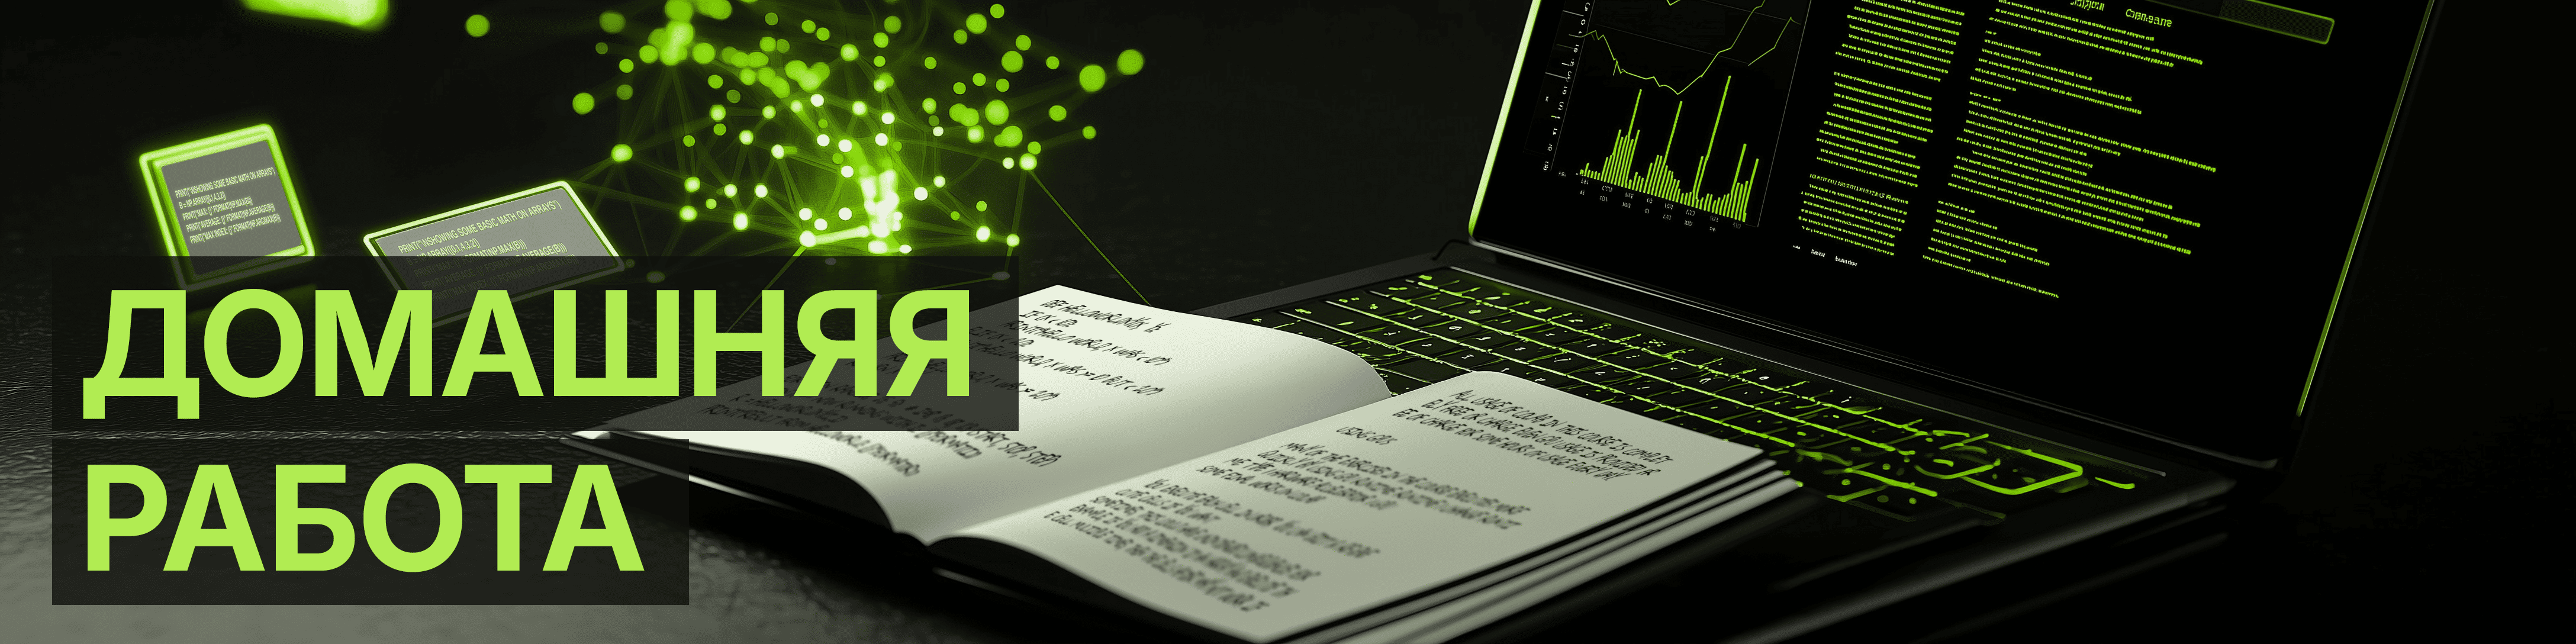

**Навигация по уроку**

1. [Keras v3. Современные подходы к CV (компьютерное зрение)](https://colab.research.google.com/drive/16ks3VjO38c7N4kXUsrdzUbunJOxRu3Fq)
2. [Перенос обучения в Keras 3.0](https://colab.research.google.com/drive/1x2qd4MvG3ODgNrE2uqxRAZB70dGgdGft)
3. [Знакомство с KerasCV](https://colab.research.google.com/drive/1ZWfrEDQaQqDmVUF0yk7N4yoMHRkXf9K-)
4. Домашняя работа

В домашней работе вам необходимо, используя пример из урока 19.2 и Keras 3, произвести тонкую настройку модели второй версии [EfficientNetV2](https://keras.io/api/applications/efficientnet_v2/) на примере набора данных [Stanford Dogs](https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip).

Баллы за задание начисляются следующим образом:
* 3 балла - дается за успешно выполненное задание с точностью на проверочной выборке не менее 75%, в задании должна быть проведена аугментация данных.
* Для получения 4-х баллов необходимо добиться, чтобы точности на проверочной и тестовой выборках были выше 75%.
* Для получения 5-ти баллов необходимо случайным образом отобрать 10 пород собак, выполнить аугментацию и добиться точности как на обучающей, так и проверочной выборках более 85%.  

In [1]:
import keras
print(keras.__version__)

3.8.0


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow import data as tf_data
import os
import keras
from keras import layers
from keras.applications import EfficientNetB0

IMAGE_SIZE = (224, 224) # Размер определен выбором модели
BATCH_SIZE = 128

In [3]:
!wget https://storage.yandexcloud.net/ai-2025/stanford%20dogs.zip

--2025-08-02 14:32:00--  https://storage.yandexcloud.net/ai-2025/stanford%20dogs.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 775644504 (740M) [application/zip]
Saving to: ‘stanford dogs.zip’

stanford dogs.zip   100%[===================>] 739.71M  24.2MB/s    in 33s     

2025-08-02 14:32:33 (22.6 MB/s) - ‘stanford dogs.zip’ saved [775644504/775644504]



In [4]:
# Разархивируем датасета во временную папку 'temp'
!unzip -qo "stanford dogs" -d ./dataset

In [5]:
# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = './dataset/dataset'

In [6]:
num_skipped = 0 # счетчик поврежденных файлов
for folder_name in os.listdir(IMAGE_PATH): # перебираем папки
    folder_path = os.path.join(IMAGE_PATH, folder_name) # склеиваем путь
    for fname in os.listdir(folder_path): # получаем список файлов в папке
        fpath = os.path.join(folder_path, fname) # получаем путь до файла
        try:
            fobj = open(fpath, "rb") # пытаемся открыть файл для бинарного чтения (rb)
            is_jfif = b"JFIF" in fobj.peek(10) # получаем первые 10 байт из файла и ищем в них бинарный вариант строки JFIF
        finally:
            fobj.close() # Закрываем файл

        if not is_jfif: # Если не нашли JFIF строку
            # Увеличиваем счетчик
            num_skipped += 1
            # Удаляем поврежденное изображение
            os.remove(fpath)

print(f"Удалено изображений: {num_skipped}")

Удалено изображений: 10


In [7]:
NEW_DIR = './selected_dogs'

In [8]:
import os
import random
import shutil

# Проверяем, существует ли директория
if os.path.exists(NEW_DIR):
    # Удаляем директорию и все её содержимое
    shutil.rmtree(NEW_DIR)
    print(f"Директория '{NEW_DIR}' была успешно удалена.")
else:
    print(f"Директория '{NEW_DIR}' не существует.")


os.makedirs(NEW_DIR, exist_ok=True)



# Получаем список всех подкаталогов (пород собак)
dog_breeds = os.listdir(IMAGE_PATH)

# Случайно выбираем 10 пород
random_dog_breeds = random.sample(dog_breeds, 10)

# Копируем выбранные папки в новую директорию
for breed in random_dog_breeds:
    src = os.path.join(IMAGE_PATH, breed)
    dst = os.path.join(NEW_DIR, breed)
    shutil.copytree(src, dst)

print("Скопированные породы собак:")
for breed in random_dog_breeds:
    print(breed)

Директория './selected_dogs' не существует.
Скопированные породы собак:
n02088094-Afghan_hound
n02099429-curly-coated_retriever
n02109961-Eskimo_dog
n02112706-Brabancon_griffon
n02109047-Great_Dane
n02111277-Newfoundland
n02097047-miniature_schnauzer
n02100236-German_short-haired_pointer
n02087394-Rhodesian_ridgeback
n02086240-Shih-Tzu


In [9]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    NEW_DIR, # путь к папке с данными
    validation_split=0.2, # отщепляем 20% на проверочную выборку
    subset="both", # указываем, что необходимо вернуть кортеж из обучающей и проверочной выборок ("training", "validation" или "both")
    seed=42,  # воспроизводимость результата генерации (результаты с одинаковым числом - одинаковы),
    shuffle=True, # перемешиваем датасет
    image_size=IMAGE_SIZE, # размер генерируемых изображений
    batch_size=BATCH_SIZE, # размер мини-батча
)

Found 1736 files belonging to 10 classes.
Using 1389 files for training.
Using 347 files for validation.


In [10]:
# Определяем список имен классов
CLASS_LIST = sorted(os.listdir(NEW_DIR))

# Определяем количества классов
CLASS_COUNT = len(CLASS_LIST)

# Вывод результата
print(f'Количество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

Количество классов: 10
Метки классов: ['n02086240-Shih-Tzu', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02097047-miniature_schnauzer', 'n02099429-curly-coated_retriever', 'n02100236-German_short-haired_pointer', 'n02109047-Great_Dane', 'n02109961-Eskimo_dog', 'n02111277-Newfoundland', 'n02112706-Brabancon_griffon']


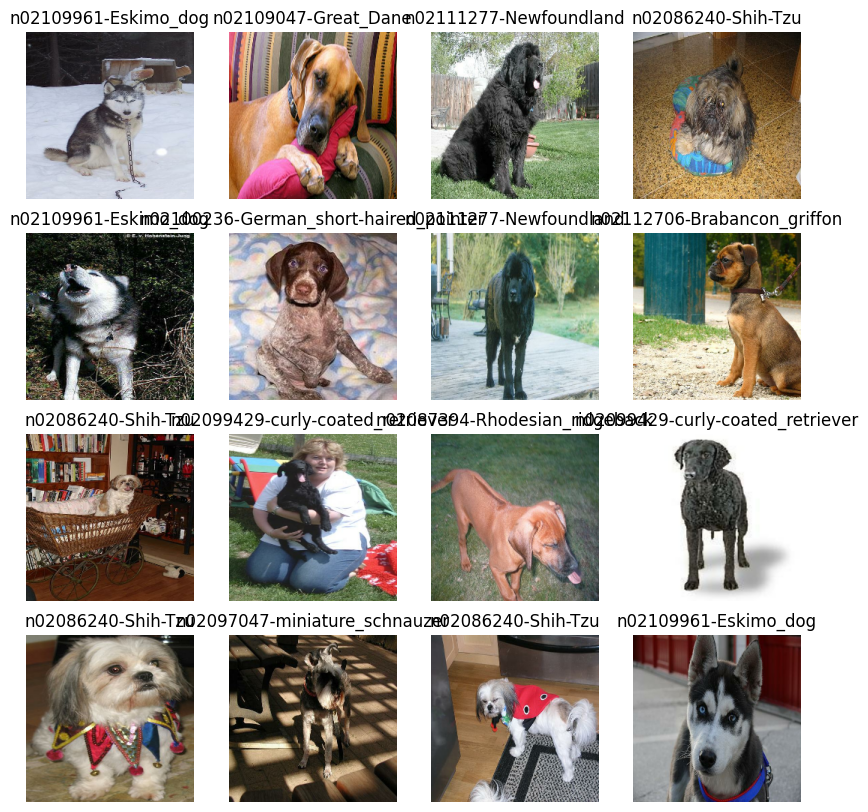

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # берем первый батч обучающей выборки
    for i in range(16): # отрисуем первые 16 картинок батча
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(images[i]).astype("uint8"))
        plt.title(CLASS_LIST[labels[i]]) # покажем метки
        plt.axis("off") # отключаем отображение осей

In [12]:
img_augmentation_layers = [
    layers.RandomRotation(factor=0.15), # Вращаем изображение в пределах 15%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Сдвиг на 10% по вертикали и горизонтали
    layers.RandomFlip(), # Отражение по вертикали и горизонтали
    layers.RandomContrast(factor=0.1), # Изменяем контрастность на 10%
]


def img_augmentation(images):
    # Слои - это функции, которые мы последовательно применяем к входным данным
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

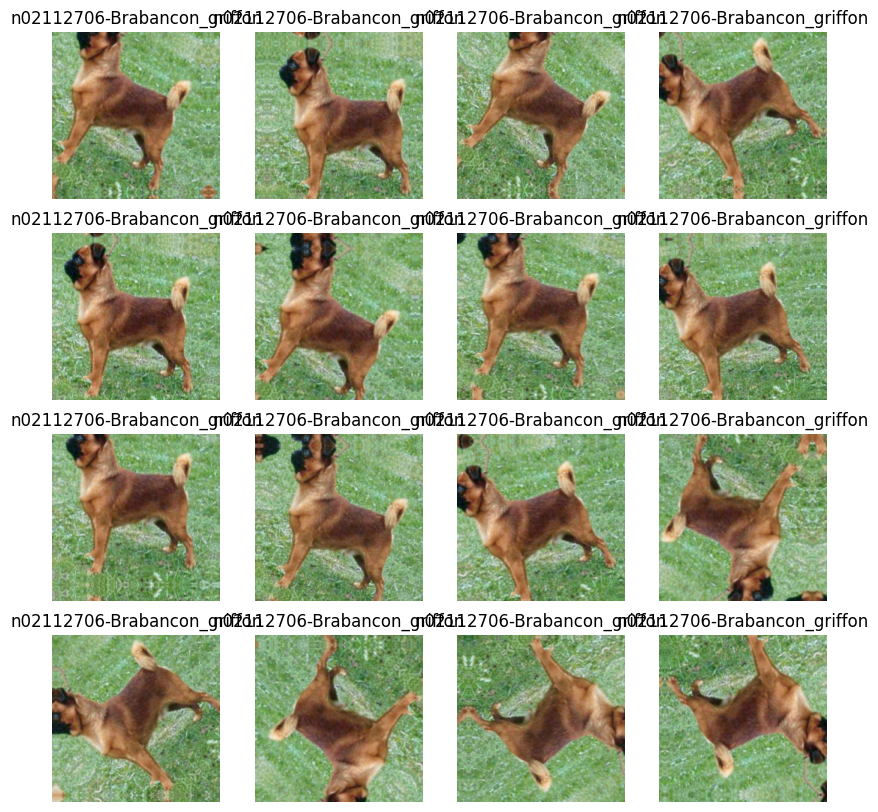

In [13]:
plt.figure(figsize=(10, 10))
for images, label in train_ds.take(1):
    for i in range(16):
        augmented_images = img_augmentation(images[0])
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(augmented_images).astype("uint8")) # Преобразуем картинку в тензор, теперь уже без NumPy
        plt.title("{}".format(CLASS_LIST[label[0]])) # Вывод метки
        plt.axis("off")

In [14]:
# Применяем `img_augmentation` к обучающей выборке
train_ds = train_ds.map(
    lambda img, label: (img_augmentation(img), keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

val_ds = val_ds.map(
    lambda img, label: (img, keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

# Предварительная выборка примеров в память GPU или оперативную память
# Помогает максимально эффективно использовать графический процессор
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

In [18]:
def show_plot(history):

    test_loss, test_accuracy = model.evaluate(val_ds)
    print(f'\nTest accuracy: {test_accuracy}')
    acc = history.history['acc']
    epochs = range(1, len(acc) + 1)
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')
    plt.plot(epochs, val_acc, 'b', label='Точность на проверочной выборке')
    plt.title('График точности на обучающей и проверочной выборках')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')
    plt.plot(epochs, val_loss, 'b', label='Потери на проверочной выборке')
    plt.title('График потерь на обучающей и проверочной выборках')
    plt.legend()
    plt.show()

In [16]:
def build_model(num_classes):
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    model = EfficientNetB0(include_top=False, input_tensor=inputs, weights="imagenet")

    # Заморозка предобученных весов
    model.trainable = False

    # Замена верхних слоев
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    # Компилируем
    model = keras.Model(inputs, outputs, name="EfficientNet")
    optimizer = keras.optimizers.Adam(learning_rate=1e-2)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["acc"]
    )
    return model

In [17]:
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_acc',
                             save_best_only = True,
                             mode = 'max',
                             verbose = 0)
]

model = build_model(num_classes=CLASS_COUNT)


history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 76s 4s/step - acc: 0.5524 - loss: 1.6130 - val_acc: 0.9424 - val_loss: 0.2039
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - acc: 0.8664 - loss: 0.5804 - val_acc: 0.9568 - val_loss: 0.1167
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - acc: 0.9001 - loss: 0.4202 - val_acc: 0.9424 - val_loss: 0.1368
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - acc: 0.9148 - loss: 0.3653 - val_acc: 0.9280 - val_loss: 0.1767
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - acc: 0.9192 - loss: 0.2953 - val_acc: 0.9625 - val_loss: 0.1379
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - acc: 0.9039 - loss: 0.3152 - val_acc: 0.9510 - val_loss: 0.1516
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - acc: 0.9300 - loss: 0.2502 - val_acc: 0.9452 - val_loss: 0.1649
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - acc: 0.9360 - loss: 0.1906 - val_acc: 0.9510 - val_loss: 0.1709
Epoch 9/20
11/11 ━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - acc: 0.9545 - loss: 0.1826

Test accuracy: 0.9538905024528503


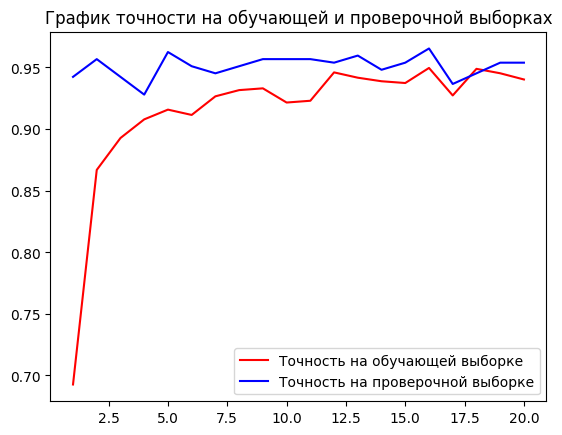

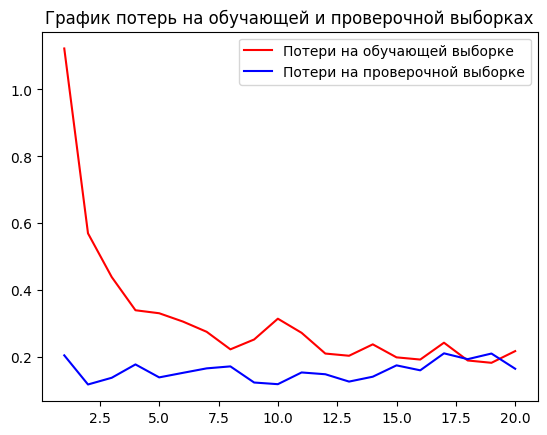

In [19]:
show_plot(history)

**Примечание**. В 2021 году появилась вторая версия модели EfficientNetV2 (https://arxiv.org/pdf/2104.00298.pdf), которая была добавлена в Keras.